In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.thorlabs import ThorCam

from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography import toolbox

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


In [2]:
cam = ThorCam()

TLCameraSDK initializing... success
Looking for cameras... success
ThorCam sn '38459' initializing... success


In [3]:
lut_path = "interpolated_voltage.lut"

slm = Meadowlark(lut_path=lut_path, wav_um=.688, settle_time_s=.3)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...

In [4]:
fs = FourierSLM(cam, slm)

In [5]:
cam.set_exposure(4e-4)

0.000398

In [ ]:
import numpy as np
from slmsuite.holography import toolbox


def phase_array(slm, n, center, span):
    """
    Generate an NxN array of spots using blazed gratings.

    center: (kx, ky) center of the array
    span:   +/- range around center in (kx, ky)
    """

    x0, y0 = center
    dx, dy = span

    xs = np.linspace(x0 - dx, x0 + dx, n)
    ys = np.linspace(y0 - dy, y0 + dy, n)

    # Complex-field superposition of the desired blazes
    field = np.zeros(slm.shape, dtype=complex)

    for ky in ys:
        for kx in xs:
            phase = toolbox.phase.blaze(
                grid=slm,
                vector=(kx, ky)
            )
            field += np.exp(1j * phase)

    # Convert complex field to a phase-only hologram
    return np.angle(field) % (2 * np.pi)


# Example
n = 2
phase = phase_array(
    slm,
    n=n,
    center=(0.02, 0.00),
    span=(0.003, 0.003)
)


slm.write(phase)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\hardware\slms\slm.py:393: UserWarning: The backwards-compatible alias SLM.write will be depreciated in favor of SLM.set_phase in a future release.
  warnings.warn(


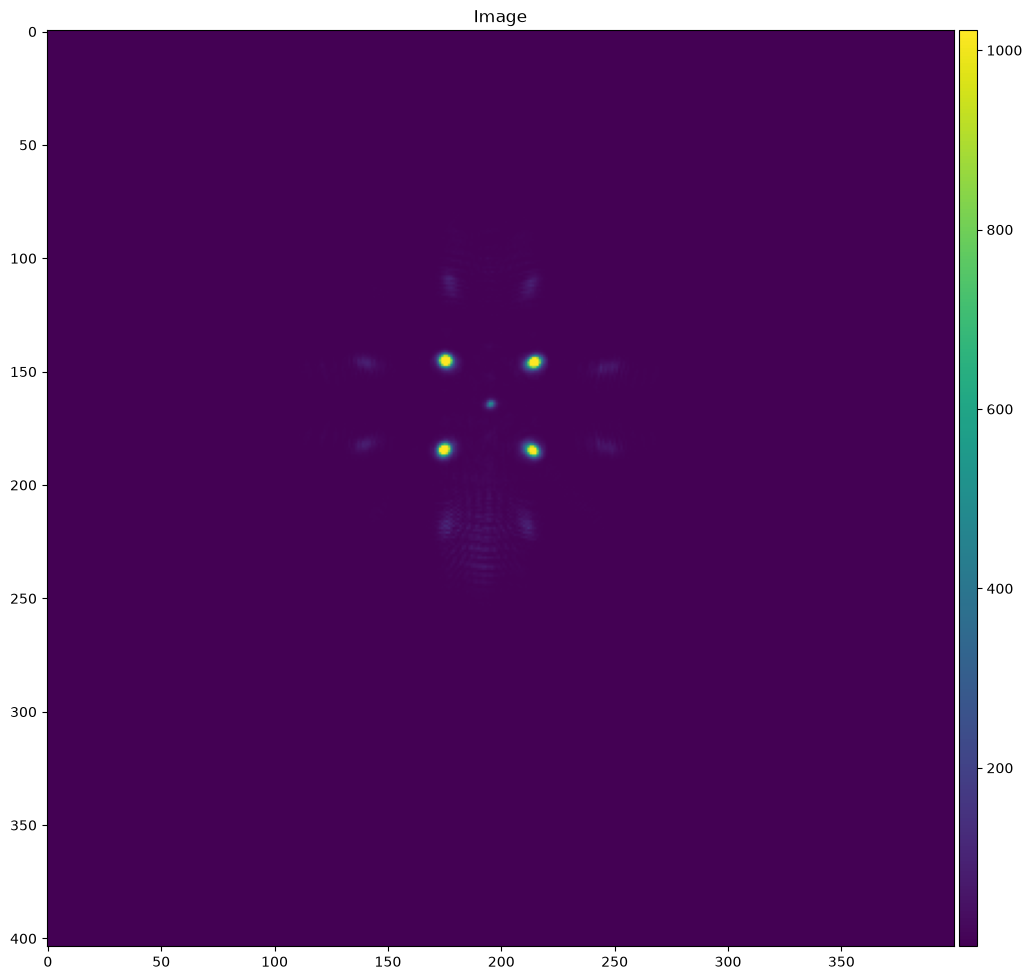

In [19]:
fs.cam.set_woi((410, 400, 350, 400))

img = fs.cam.get_image()                                        # Grab image.

plt.figure(figsize=(12,12))
fs.cam.plot(img);